# JetVLAD Tutorial: Training and Plotting the Results
This tutorial trains the JetVLAD heavy-flavor tagger from a preselected .root file and then validates the training against preselected validation and test .root files. The resulting ROC and background rejection curves are plotted.
### WARNING: This notebook must sit in the repository folder next to train.py, utils.py and model/, all the model and dataset code lives in those files.

Paper: [Identifying Heavy-Flavor Jets Using Vectors of Locally Aggregated Descriptors](https://arxiv.org/abs/2005.01842)

## 1. Setup
The first step is to setup the necessary packages to read the data in the .root files. This is performed by "pip install" below.

In [2]:
# Install anything missing (pip skips packages already present).
%pip install -q torch numpy scikit-learn matplotlib uproot


Note: you may need to restart the kernel to use updated packages.


In [6]:
# On Colab: clone the repository if we are not already inside it.
import os
REPO_URL = 'https://github.com/cplatte24/NetVLAD-tagger-pytorch.git'

if not os.path.isfile('train.py'):
    if REPO_URL:
        !git clone {REPO_URL} repo
        %cd repo
    else:
        raise FileNotFoundError('train.py not found - run this notebook from the '
                                'repository folder, or set REPO_URL above.')
print('working directory:', os.getcwd())


working directory: /Users/plattecw/JetVLAD_JupyterNotebook/NetVLAD-tagger-pytorch


## 2. Configuration
In the configuration, the path to the training, validation, and test paths are set. Additionally, the input variables to the model used for the jet classificiation are set (VARIABLES). The table below shows what input variables are the model can be trained on (tracking, fragmentation, and secondary vertex).<br> <img src="https://raw.githubusercontent.com/cplatte24/NetVLAD-tagger-pytorch/main/notebook_images/image.png" width="500"> <br>

In [8]:
# The path to the .root files, the default is set to preuploaded files.
TRAIN_PATH = 'training_data/output_5to10_9_fixed.root'
VAL_PATH   = 'validation_data/output_5to10_validation_all.root'
TEST_PATH  = 'testing_data/output_5to10_test_all.root'

# Model parameters
VARIABLES = 'trkvtx' #The variables: trk, vtx, trkvtx, trkfrag, trkvtxfrag
CLUSTERS  = 33
DEPTH     = 2
SIGNAL    = 'hf_vs_l' #The signal: c_vs_b, hf_vs_l, c_vs_all, b_vs_all
JOBID     = 'jetvlad_notebook_run'   # outputs located in training_runs/<JOBID>/

for p in (TRAIN_PATH, VAL_PATH, TEST_PATH):
    assert os.path.isfile(p), f'missing input file: {p}'
    print(f'{p}: {os.path.getsize(p)/1e6:.0f} MB')

# Pretrained model: True loads the checkpoint below instead of training (fast).
# Set to False to train your own model with the settings above.
USE_PRETRAINED = True
PRETRAINED_PATH = 'jetvlad_trained.pth'   # trkvtx / 33 clusters / depth 2, trained on the full sample


training_data/output_5to10_9_fixed.root: 29 MB
validation_data/output_5to10_validation_all.root: 43 MB
testing_data/output_5to10_test_all.root: 43 MB


## 3. Test the Model (or train it yourself!)

#### By default USE_PRETRAINED = True, so this step is skipped and the next cell evaluates the pretrained checkpoint shipped with the repository instead. Set USE_PRETRAINED = False in the configuration cell to train your own model here.
<br>

The cell below runs the training (train.py) in a separate process with the
arguments above. Training uses early stopping on validation loss and when it finishes, it
evaluates on the test sample and writes the curves to
training_runs/<JOBID>/*_roc.txt and *_pr.txt. The progress prints below as it runs.
    <br>
Note: Loading the TTrees into memory can take a while (15-20 minutes) before the first epoch starts if you decide to train it yourself.




In [16]:
# Runs only when USE_PRETRAINED = False in the configuration cell.
if USE_PRETRAINED:
    print('Using the pretrained model - skipping training.')
    print('Set USE_PRETRAINED = False in the configuration cell to train your own.')
else:
    !python train.py \
            --train-data {TRAIN_PATH} \
            --test-data {TEST_PATH} \
            --val-data {VAL_PATH} \
            --variables {VARIABLES} \
            --clusters {CLUSTERS} \
            --depth {DEPTH} \
            --signal {SIGNAL} \
            --jobid {JOBID}


Using the pretrained model - skipping training.
Set USE_PRETRAINED = False in the configuration cell to train your own.


Below the ROC-AUC (Receiver Operating Characteristic — Area Under the Curve) will be provided. This is a single-number summary of how well the tagger separates the two classes. Pick one random heavy-flavor jet and one random light jet from the test set; an ROC-AUC of x means there is a probability x that the model scores the heavy-flavor jet higher. A bad classifier gives 0.5 (coin flip), a perfect one 1.0.

In [10]:
# Pretrained path: load the shipped checkpoint and evaluate it on the test sample.
# Writes the same *_roc.txt / *_pr.txt files a training run would, so the plots
# below work identically. Runs only when USE_PRETRAINED = True.
if USE_PRETRAINED:
    import torch
    from pathlib import Path
    from model.tagger import NetVLADTagger
    from utils import JetVectorDataset, collate_fn, test

    FEATURES = {'trk': 3, 'vtx': 2, 'trkvtx': 5, 'trkfrag': 6, 'trkvtxfrag': 8}[VARIABLES]
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = NetVLADTagger(CLUSTERS, FEATURES, DEPTH)
    model.load_state_dict(torch.load(PRETRAINED_PATH, map_location='cpu'))
    model.to(device).eval()

    print('Loading test data...')
    test_data = JetVectorDataset(TEST_PATH, signal=SIGNAL, variables=VARIABLES, track_shuffling=False)
    loader = torch.utils.data.DataLoader(test_data, batch_size=256, shuffle=False,
                                         num_workers=2, collate_fn=collate_fn)

    run_dir = os.path.join('training_runs', 'pretrained_eval')
    os.makedirs(run_dir, exist_ok=True)
    auc_val = test(loader, Path(run_dir) / 'pretrained_eval.txt', model, generate_curve=True)
    print(f'Test-set ROC-AUC: {auc_val:.4f}')


Loading test data...
Test-set ROC-AUC: 0.9850


## 4. Plot the results

Reads the *_roc.txt and *_pr.txt files written in the previous step and plots them.


In [11]:
# Curve averaging, from make_plots.py (paths parameterized instead of hardcoded).
import glob
import numpy as np
from sklearn.metrics import auc

run_dir = os.path.join('training_runs', 'pretrained_eval' if USE_PRETRAINED else JOBID)
mean_fpr = np.linspace(0.0001, 1, 8000)
mean_rec = np.linspace(1, 0.0001, 8000)

def generate_roc_curve(folder):
    tprs, aucs = [], []
    for file in glob.glob(os.path.join(folder, '*_roc.txt')):
        fpr, tpr = np.loadtxt(file)
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0001
        aucs.append(auc(fpr, tpr))
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    std_tpr = np.std(tprs, axis=0)
    print(f'{len(tprs)} ROC file(s), mean AUC {auc(mean_fpr, mean_tpr):.4f} +- {np.std(aucs):.4f}')
    return mean_tpr, np.minimum(mean_tpr + std_tpr, 1), np.maximum(mean_tpr - std_tpr, 0)

def generate_pr_curve(folder):
    precs = []
    for file in glob.glob(os.path.join(folder, '*_pr.txt')):
        prec, rec = np.loadtxt(file)
        precs.append(np.interp(mean_rec[::-1], rec[::-1], prec[::-1]))
        precs[-1][0] = 1
    mean_prec = np.mean(precs, axis=0)[::-1]
    mean_prec[-1] = 1
    std_prec = np.std(precs, axis=0)
    return mean_prec, np.minimum(mean_prec + std_prec, 1), np.maximum(mean_prec - std_prec, 0)

tpr_trkvtx, tprs_upper, tprs_lower = generate_roc_curve(run_dir)
prec_trkvtx, precs_upper, precs_lower = generate_pr_curve(run_dir)

# Legend text - edit to match your sample.
label_title = ('JetVLAD, Pythia8, cross-section weighted\n'
               r'$\sqrt{s} = 200$ GeV, thermal bkg, anti-$k_{T}$ jets R = 0.4' + '\n'
               r'$5 < p_{T,jet} < 10$ GeV/$c$, $|\eta_{jet}| < 0.6$')


1 ROC file(s), mean AUC 0.9850 +- 0.0000


### What are the efficiency, background rejection, and purity?
The two cells after this section will provide two separate plots for background rejection and purity vs efficiency. What are these quantities you may ask?
<br>
<br>
First, **efficiency** is defined as 
<br>
$$TPR = \frac{TP}{P}$$
<br> 
where 
**TP** is the number of positively identified heavy-flavor jets and **P** is the total number of heavy-flavor
jets in the testing sample.
<br>
<br>
Background rejection (**REJ**) is given by one over the false positive rate (**FPR**)
<br>
$$REJ = \frac{1}{FPR}$$

where $$FPR = \frac{FP}{N}$$

Here **FP** is a number of false-positive samples identified in the testing sample and **N** is the total number
of background objects in the testing sample.

**REJ** is useful as it determines how much of the true background will be rejected per one false-positive detection.
It is a useful quantity particularly for heavy-flavor jet classification where the signal is two orders
of magnitude smaller than the background due to the difference in the production cross-sections.
<br>
<br>
Purity on the other hand is defined as 
<br>
$$PREC = \frac{TP}{TP+FP}$$
<br>
where **TP** is the number of true positive objects found in the testing sample and **FP** is the number of
false positive objects found in the testing sample. As its name suggests, this metric tells us the
extent of contamination in the signal with false-positive objects. 

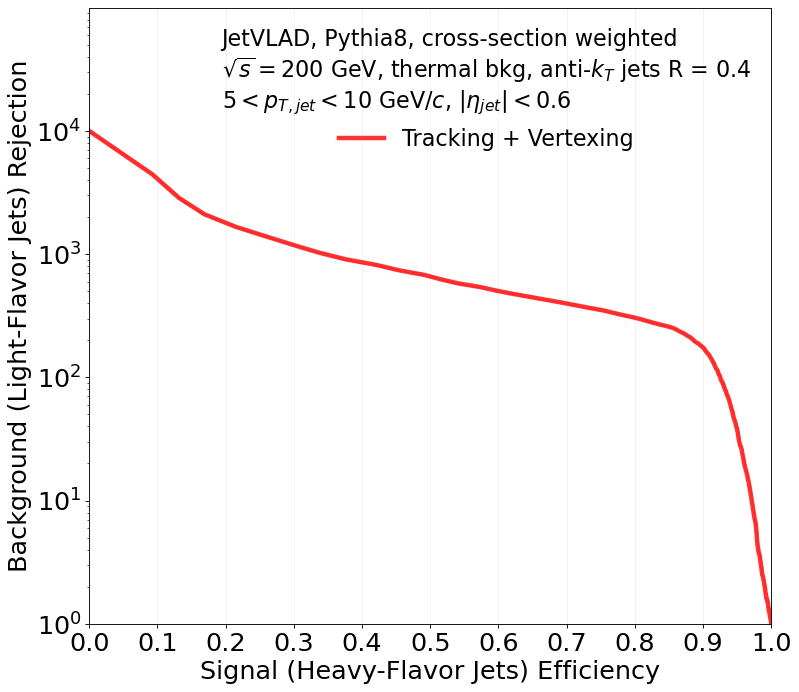

In [17]:
# Background rejection vs signal efficiency (make_plots.py layout).
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 10), dpi=80, facecolor='w', edgecolor='k')
plt.plot(tpr_trkvtx, 1/mean_fpr, color='red', label=r'Tracking + Vertexing',
         lw=4, alpha=.8, linestyle='-')
plt.fill_betweenx(1/mean_fpr, tprs_lower, tprs_upper, color='red', alpha=.2)
plt.xlim([0, 1])
plt.xticks(np.arange(0, 1.1, 0.1), fontsize=23)
plt.yscale('log')
plt.ylim([1e0, 1e5])
plt.yticks([1e0, 1e1, 1e2, 1e3, 1e4], fontsize=23)
plt.grid(axis='x', color='0.95')
plt.xlabel('Signal (Heavy-Flavor Jets) Efficiency', fontsize=23)
plt.ylabel('Background (Light-Flavor Jets) Rejection', fontsize=23)
plt.legend(loc='upper right', fancybox=True, framealpha=0., fontsize=20,
           title=label_title, title_fontsize=20)
plt.savefig('netvlad_rejection.pdf', bbox_inches='tight')
plt.show()


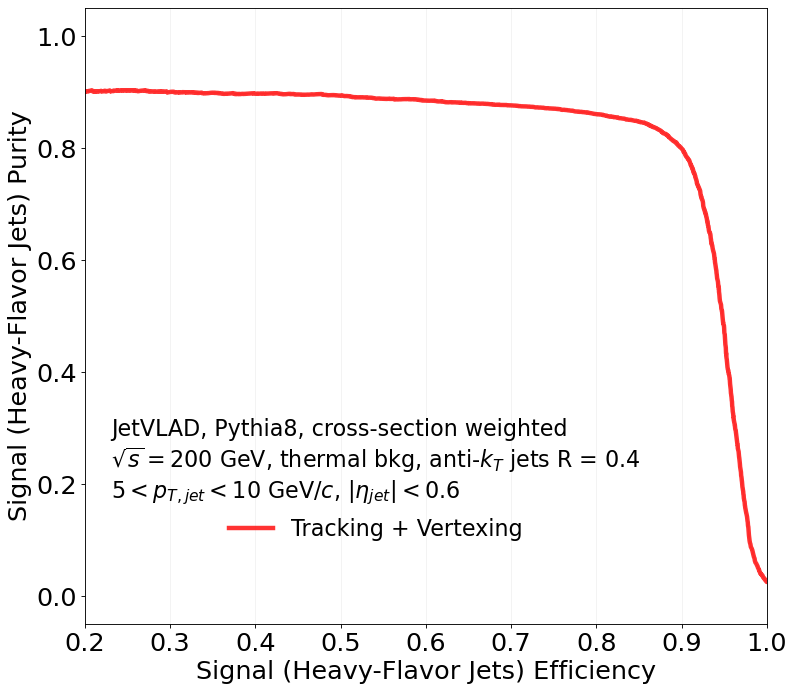

In [18]:
# Signal purity vs signal efficiency (make_plots.py layout).
plt.figure(figsize=(11, 10), dpi=80, facecolor='w', edgecolor='k')
plt.plot(mean_rec, prec_trkvtx, color='red', label=r'Tracking + Vertexing',
         lw=4, alpha=.8, linestyle='-')
plt.fill_between(mean_rec, precs_lower, precs_upper, color='red', alpha=.2)
plt.xlim([0.2, 1])
plt.ylim([-0.05, 1.05])
plt.grid(axis='x', color='0.95')
plt.xticks(np.arange(0.2, 1.1, 0.1), fontsize=23)
plt.yticks(fontsize=23)
plt.xlabel('Signal (Heavy-Flavor Jets) Efficiency', fontsize=23)
plt.ylabel('Signal (Heavy-Flavor Jets) Purity', fontsize=23)
plt.legend(loc=(0.025, 0.12), fancybox=True, framealpha=0., fontsize=20,
           title=label_title, title_fontsize=20)
plt.savefig('netvlad_purity.pdf', bbox_inches='tight')
plt.show()


In [15]:
# Working points, same printout as make_plots.py.
idx_eff_80 = np.abs(0.80 - tpr_trkvtx).argmin()
idx_pur_80 = np.abs(0.80 - mean_rec).argmin()
idx_eff_50 = np.abs(0.50 - tpr_trkvtx).argmin()
idx_pur_50 = np.abs(0.50 - mean_rec).argmin()
print('Rejection@80eff: ', 1/mean_fpr[idx_eff_80])
print('Prec@80eff: ', prec_trkvtx[idx_pur_80])
print('Rejection@50eff: ', 1/mean_fpr[idx_eff_50])
print('Prec@50eff: ', prec_trkvtx[idx_pur_50])


Rejection@80eff:  310.07000705497455
Prec@80eff:  0.8601619676572637
Rejection@50eff:  677.9503000305116
Prec@50eff:  0.8934557042894036
